# Quick Overview: Cross-Correlation and Likelihood Mapping


This section performs cross-correlation analysis to detect planetary signals, following methods outlined in 
Boucher et al. (2021, 2023) and Gibson et al. (2020). Two approaches are provided:

1. Quick Correlation:
   - Standard cross-correlation using shifted and interpolated model spectra.
   - Optionally computes log-likelihood using either the Brogi-style ('BL'), Gibson-style ('GG'), or optimized ('OG') methods.
$\newline$
2. Injection Correlation:
   - Injects a model at each Kp across all exposures.
   - More computationally intensive, but better for modeling and recovering full transmission spectra.

Functions also include likelihood calculation, velocity models, and plotting utilities for correlation maps and significance testing. Our tutorial will only run through the injected correlation method.

# The notebook is set up for HD 189733b SPIRou data. Your task is to set up this notebook to run STARSHIPS for WASP-127b given the data in this container from NIRPS. Warning: there are also missing parameters and files which will trigger errors

In [1]:
#we are NOT running petitRADTRANS in this tutorial however, starships needs it to run. 
#we are tricking the container here to believe we have petitRADTRANS when infact all the functions are empty

import sys
import types

# Top-level dummy package
petitRADTRANS = types.ModuleType("petitRADTRANS")

# Submodules as separate mock modules/namespaces
petitRADTRANS.Radtrans = object  # or define a dummy class

petitRADTRANS.nat_cst = types.SimpleNamespace()
petitRADTRANS.physics = types.SimpleNamespace(
    guillot_global=lambda *a, **k: None,
    guillot_modif=lambda *a, **k: None
)
petitRADTRANS._read_opacities = types.SimpleNamespace()
petitRADTRANS.fort_input = types.SimpleNamespace()
petitRADTRANS.fort_rebin = types.SimpleNamespace()
petitRADTRANS.pyth_input = types.SimpleNamespace()

poor_mans_nonequ_chem = types.ModuleType("poor_mans_nonequ_chem")
poor_mans_nonequ_chem.interpol_abundances = lambda *a, **k: None

# Register everything in sys.modules
sys.modules["petitRADTRANS"] = petitRADTRANS
sys.modules["petitRADTRANS.radtrans"] = petitRADTRANS
sys.modules["petitRADTRANS._read_opacities"] = petitRADTRANS._read_opacities
sys.modules["petitRADTRANS.fort_input"] = petitRADTRANS.fort_input
sys.modules["petitRADTRANS.fort_rebin"] = petitRADTRANS.fort_rebin
sys.modules["petitRADTRANS.pyth_input"] = petitRADTRANS.pyth_input
sys.modules["petitRADTRANS.nat_cst"] = petitRADTRANS.nat_cst
sys.modules["petitRADTRANS.physics"] = petitRADTRANS.physics
sys.modules["petitRADTRANS.poor_mans_nonequ_chem"] = poor_mans_nonequ_chem

In [2]:
#Import the starships parameters

from sys import path
import os
import numpy as np

from pathlib import Path

from sys import path

import matplotlib.pyplot as plt
from importlib import reload
import starships.plotting_fcts as pf 

import astropy.units as u
import astropy.constants as const

from starships import homemade as hm
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [ ]:
import logging
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)  # stop printing a ton of INFO lines everywhere

In [3]:
#import Starships Function

from starships.correlation_class import Correlations
import starships.correlation_class as cc

import starships.planet_obs as pl_obs
from starships.planet_obs import Observations,Planet
import starships.correlation as corr
from itertools import product

In [4]:
# %matplotlib notebook
%matplotlib inline
couleurs = hm.get_colors('magma', 50)[5:-2]

# Load in the reduction files

This section loads the reduction files that were generated in the previous notebook.
We'll also define the planet parameters here — make sure they match the ones used in the earlier reduction step.

In [5]:

#input planet name this will pull from exofile, so can change any parameters here

#here we can overwrite the parameters that are given from exofile


pl_name='HD 189733 b'
planet_obj=Planet(pl_name)
planet_obj.ap  = 0.08*u.au       # semi-major axis of planet
planet_obj.R_star = 2.5*u.R_sun      # radius of star
planet_obj.R_pl = 1.9*u.R_earth    # radius of planet
planet_obj.M_star = 0.5*const.M_sun  # mass of star


INFO:starships.planet_obs:Getting WASP-127 b from ExoFile


In [6]:
#give a path to the files we reduced in the previous notebook, this is the same as your outdir in the previous notebook
reduc_dir = '/home/jovyan/data/WASP-127b_container_TEST'


In [7]:
#list the file names you would like to use here
filename_list = ['sequence_2-']
obs_list = []

#this will run through all of the name and create an "obs_list"(a list of our observations)

for filename in filename_list:
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)
    obs_list.append(obs)
    
#the obs list will have all of the information from the reduction files

Transmission


# Next we Need to load in the Model
In this notebook, we aren't supposed to build the model from scratch. Instead, the model should have already been created in a previous notebook, often called something like make_a_model. That earlier notebook uses PetitRADTRANS (PRT) to generate a planetary atmosphere model and saves it to a file.

Here, we simply load that precomputed model so we can analyze it or compare it to data. This approach saves time and ensures consistent results, because generating the model with PRT can take a while and depends on many input parameters.

PetitRADTRANS is a tool for simulating the transmission or emission spectra of exoplanet atmospheres, based on properties like temperature, composition, and pressure.

Text(0.5, 1.0, 'model_NIRPS-APERO_H2O_main_iso_FeH_main_iso_CO_all_is')

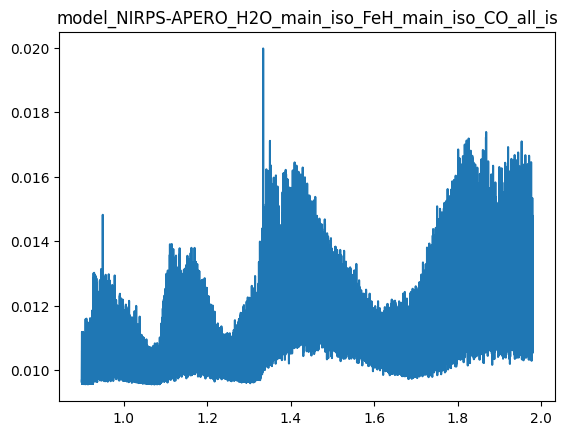

In [8]:
# Path to and name of the model file
model_file = np.load('/home/jovyan/Models/model_NIRPS-APERO_H2O_main_iso_FeH_main_iso_CO_all_iso.npz')
wave_mod_comb, model_spec_comb = model_file['wave_mod'], model_file['mod_spec']

# Plot it
plt.plot(wave_mod_comb, model_spec_comb)
plt.title('model_NIRPS-APERO_H2O_main_iso_FeH_main_iso_CO_all_is')

Text(0.5, 1.0, 'model_NIRPS-APERO_H2O_pokazatel_main_iso')

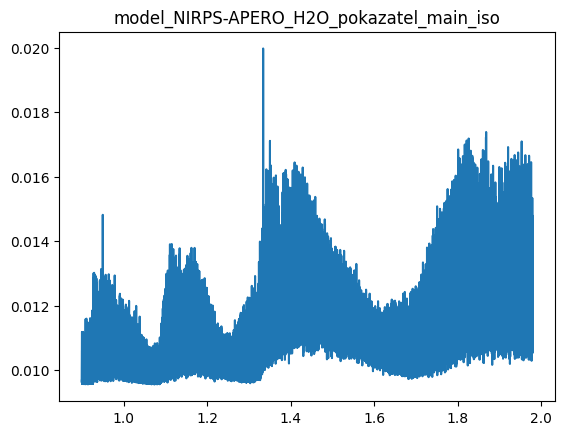

In [9]:
#find the other model and load it in the same way. Is there a difference? Can you overplot them?
model_file_h20 = np.load()
wave_mod_h20, model_spec_h20 = 

plt.plot(wave_mod_h20, model_spec_h20)
plt.title('model_NIRPS-APERO_H2O_pokazatel_main_iso')

# Lets run the Injection Correlation

First we need to define a few extra parameters and then we are ready to run!

In [10]:
# define some arrays for the correlation, this is based on Spirou right now

n_RV_inj=151
corrRV0 = np.linspace(-150, 150, n_RV_inj)
Kp_array = np.array([obs.Kp.value]) 
kind_trans = 'emission'


In [15]:
#where do you want the proucts stored?
output_dir = '/home/jovyan/data/WASP-127b_container_TEST/'

print(output_dir)

/home/jovyan/data/WASP-127b_container_TEST/


In [16]:
#define what you want as the model for the cross correlation

wave_mod, model_spec =


In [27]:
#put in a model name and visit name
model_name = 
visit_name = 

#file name for the reduction you would like to crosss correlate
filename_list = [f'sequence_{n_pc}-pc_mask_wings{mask_w}'
                 for mask_w, n_pc in product([90], range(2, 3))]
print('\n'.join(filename_list))

n_pc_list = []
mask_wings_list = []
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()


for filename in filename_list:
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)
    
    # Generate Kp 
    Kp_array = np.array([obs.Kp.value]) 
        
    n_pc = int(obs.params[5])
    n_pc_list.append(n_pc)
    
    mask_wings = int(obs.params[1] * 100)  # in percent
    mask_wings_list.append(mask_wings)
    
    out_filename = f'{Path(filename).stem}_ccf_logl_seq_{model_name}'
    
    # try:
    #     # Check if already generated
    #     saved_values = np.load(output_dir / Path(out_filename).with_suffix('.npz'))
    #     ccf_map = saved_values['corr']
    #     logl_map = saved_values['logl']
        
    # except FileNotFoundError:
        # Generate 1d correlations
        # ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
    ccf_map, logl_map = corr.calc_logl_injred(
        obs,'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec,  kind_trans
    )


    corr.save_logl_seq(output_dir / Path(out_filename), ccf_map, logl_map,
                        wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)


    all_obs[(n_pc, mask_wings)] = obs
    all_ccf_map[(n_pc, mask_wings)] = ccf_map
    all_logl_map[(n_pc, mask_wings)] = logl_map

sequence_2-pc_mask_wings90
Transmission
Injecting model w/ alpha = ones
Starting with 2 PCs
Computing with
Saved correl at : /home/jovyan/data/WASP-127b_container_TEST/sequence_2-pc_mask_wings90_ccf_logl_seq_H2O.npz


In [29]:
#confirm that the products are all the correct shape

print(np.shape(all_logl_map))
# print(all_logl_map)
# print(order_indices)

()


# Thats it! Lets look at the results!

This can also be done in a seperate notebook

Transmission
Max value at 2 pc = -0.09050231317463586 at -5.455086309838389 km/s
Max value at 2 pc = 0.13654031382374554 at -5.400350037819604 km/s
Max value at 2 pc = 0.13654031382374554 at -5.400350037819604 km/s


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'MATH': 35 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'C', 'F', 'I', 'L', 'N', 'R', 'S', 'a', 'b', 'c', 'eight', 'five', 'four', 'g', 'hyphen', 'l', 'minus', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 's', 'seven', 'six', 'slash', 'space', 'three', 'two', 'uni0394', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 37, 38, 41, 44, 47, 49, 53, 54, 68, 69, 70, 74, 79, 82, 83, 86, 809, 3228]
INFO:fontTools.subset:Closed glyph list over 'MATH': 35 glyphs after
INFO:fontTools.sub

[-0.09050231]
[-2170.43569736]
[0.43172023]
[0.]
(56, 151)


INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 5 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'space', 'v']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 89]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 5 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'space', 'v']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 89]
INFO:fontTools.subset:Closing glyph list over 'glyf': 5 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'nonmarkingreturn', 'space', 'v']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 

Saved file to :   fig_CCF_2D .pdf
(array([54, 55]),)
In-transit t-val = 0.10 / p-val 9.21e-01 / sig = -1.41
Out-of-transit t-val = -2.13 / p-val 4.07e-02 / sig = 1.74


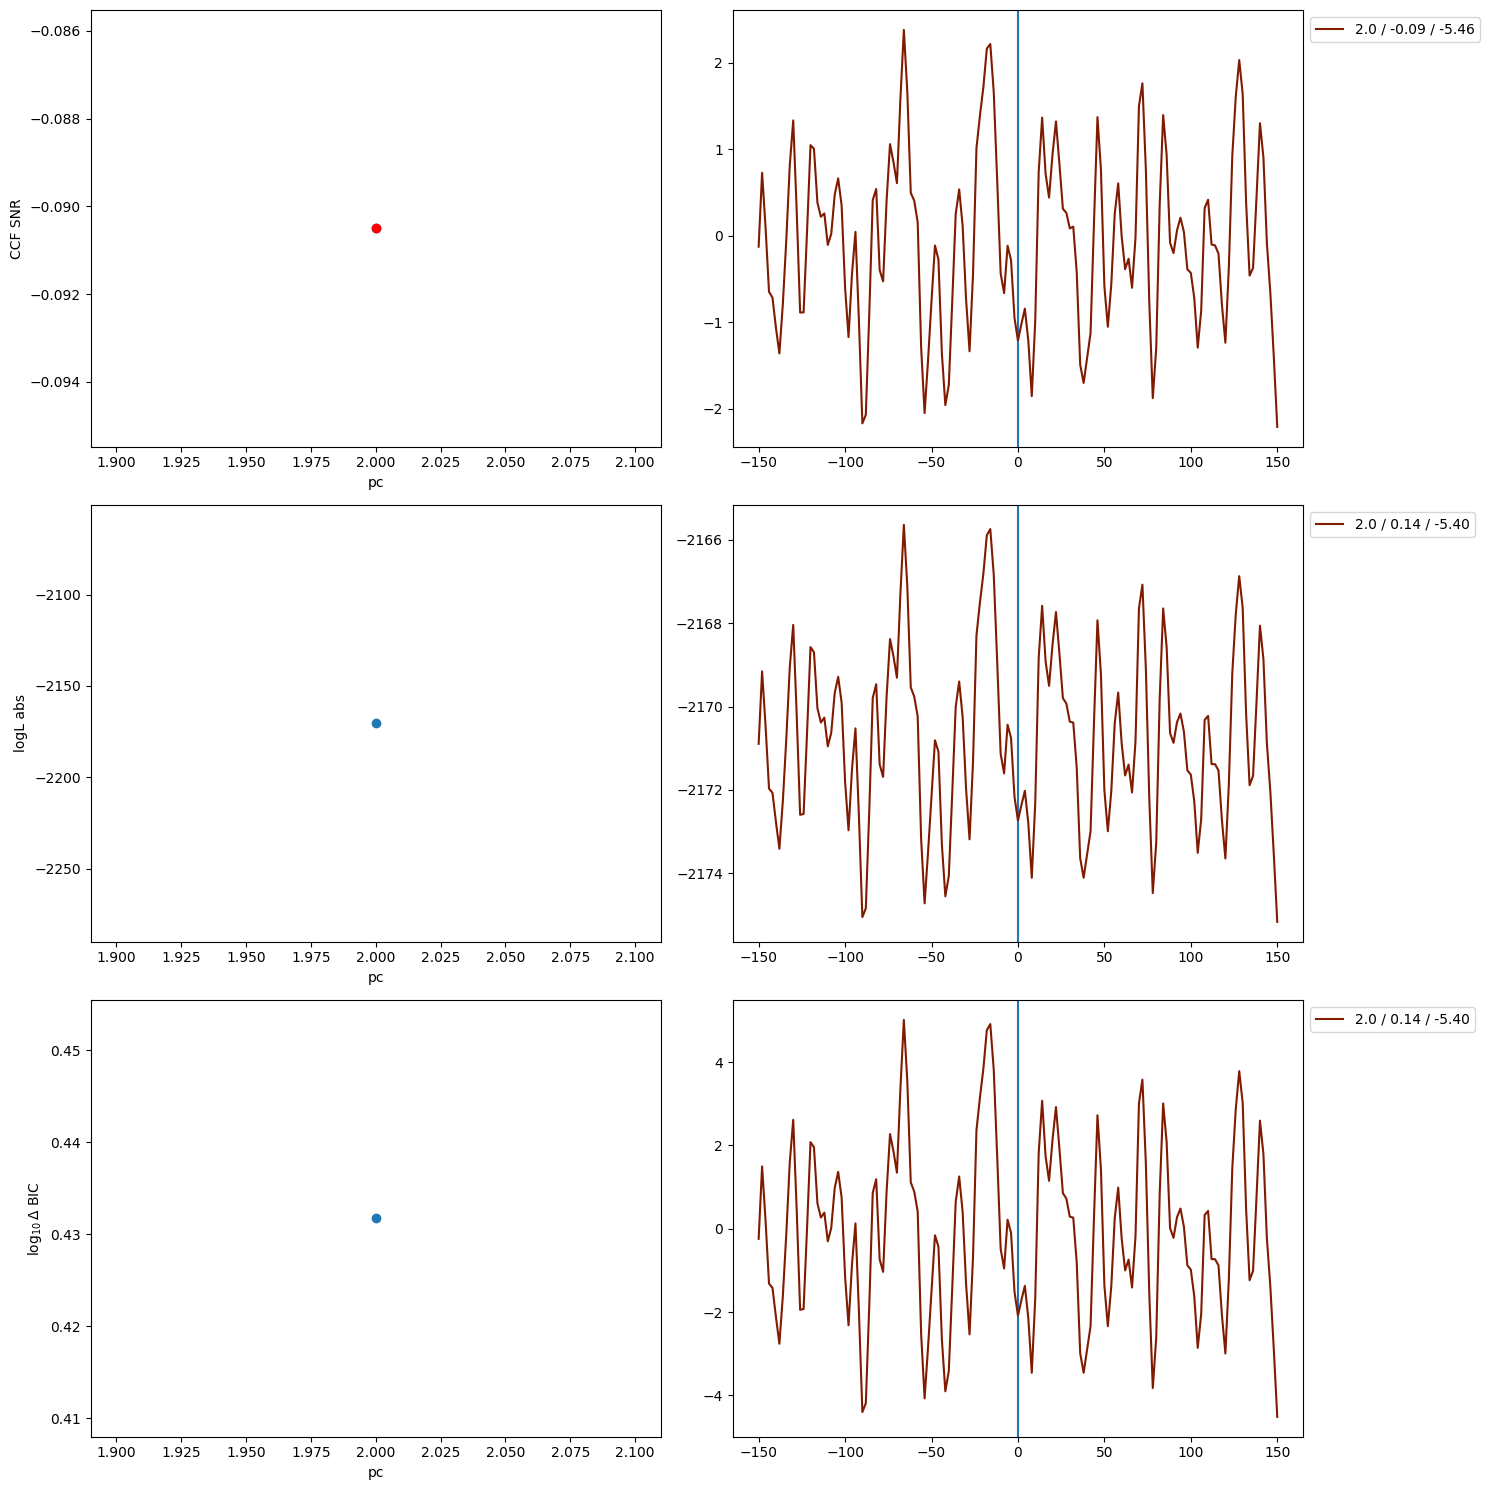

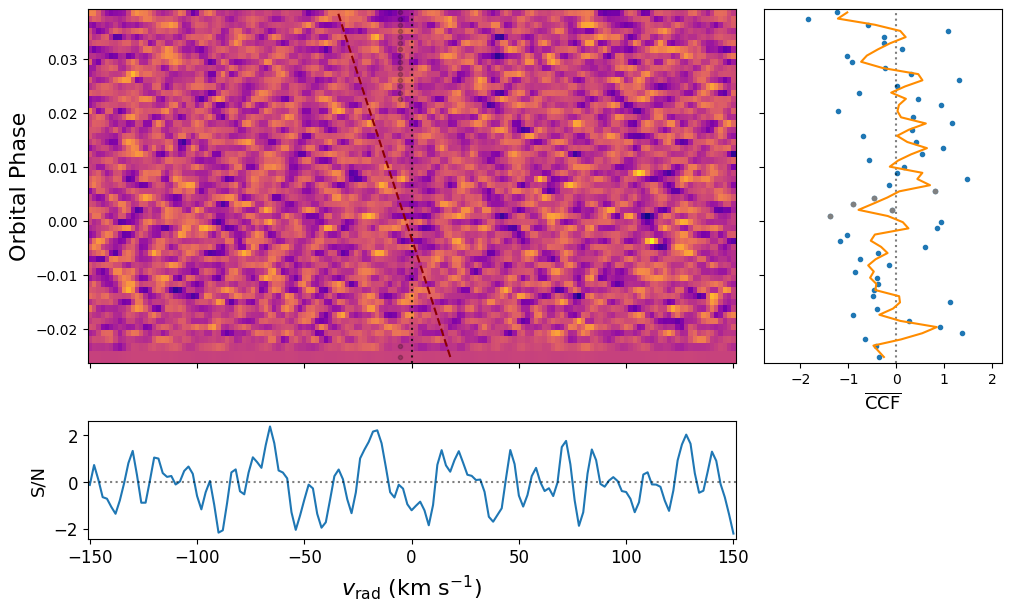

In [35]:
# Plot single ccf and logl
n_pc, mask_wings = 

#indices you would like to include in the ccf
#what orders give the best detections? can you use them all?
order_indices=[46,47]

#reducction file name to look at
filename = f'sequence_2-pc_mask_wings90'
obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir,
                              load_all=False, filename_end='', plot=False, planet=planet_obj)

args = [all_something[(n_pc, mask_wings)]
        for all_something in [all_obs, all_ccf_map, all_logl_map]]

# calculate the ccf and logl_obj from the reduction files using the calculations from above
ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc], orders=order_indices,path_fig=" ",fig_name=" ")


# Generate the T-test

The t-test will be used to evaluate the null hypothesis that the two samples—typically in-transit and out-of-transit data—are drawn from the same underlying distribution. In this context, the test assesses whether any observed difference between the two datasets (such as the strength of a spectral feature or cross-correlation signal) is statistically significant or simply due to random noise. If the graph of in and out look the same, there is no clear detection.

T-val : Max value = 4.0 // Max position = -14.0
Histogram for Kp = 129.87 and RV = -5.46
0.044832041622762366 0.9643146953645865 -1.8031121125141951


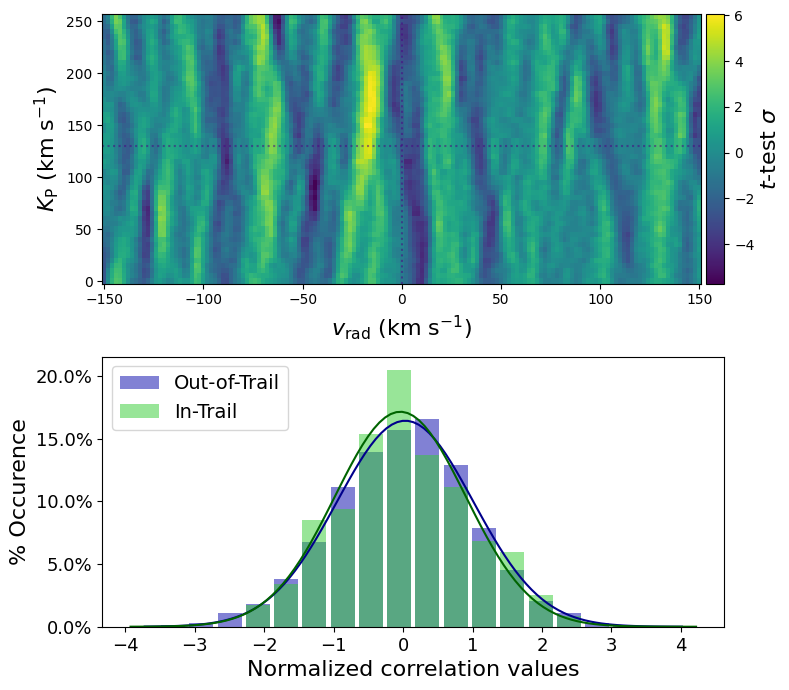

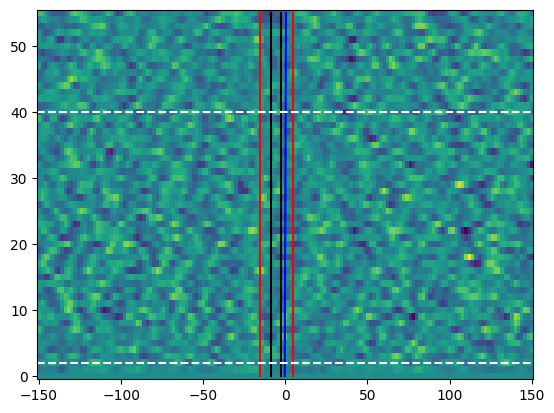

<Figure size 640x480 with 0 Axes>

In [38]:
# Generate the ttest map
#try changing the parameters here

ccf_obj.ttest_map(all_obs[(n_pc, mask_wings)], kind='logl', vrp=np.zeros_like(obs.vrp), orders=order_indices, 
                  kp0=0, RV_limit=150, kp_step=5, rv_step=2, RV=None, speed_limit=3, equal_var=False
                  )

# Normalize the significance

To accurately represent the significance in a Kp/Vsys map, we normalize the t_value map so that the minimum corresponds to -3σ. This ensures consistency with our sigma claims. We can use only certain part of the test map, or scale the entire map.


T-val : Max value = 2.1 // Max position = -14.0
Histogram for Kp = 129.87 and RV = -5.46


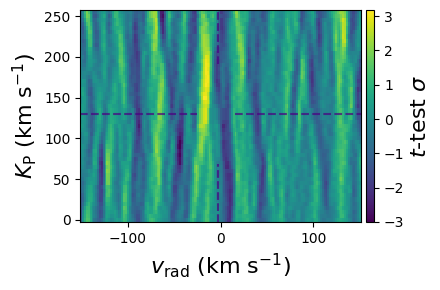

In [40]:
#pull in the objects described above
tr=all_obs[(n_pc, mask_wings)]
cobj = ccf_obj
t_value = cobj.ttest_map_tval

#scale using the entire map:
t_value_scaled = t_value*(-3)/t_value.min()

#an example to scale only using a certain part of the map:
# kp_index = cobj.ttest_map_kp < 140
# t_value_scaled = t_value * (-3) / np.nanmin(t_value[kp_index, :])

#run the function to plot the ttest map 
(t_in, p_in) = pf.plot_ttest_map_hist(tr, cobj.rv_grid, cobj.map_prf.copy(), 
                                           cobj.ttest_map_kp, cobj.ttest_map_rv, 
                                    t_value_scaled, cobj.ttest_map_params, 
                              plot_trail=True, masked=True, ccf=cobj.map_prf.copy(),
                              vrp=np.zeros_like(tr.vrp), RV=cobj.pos, hist=False,
                                      show_max=False, show_rest_frame=False,
                                    fig_name='', path_fig=None, orders=order_indices)

fig = plt.gcf()
ax = fig.axes

pos_max = -3.2
# - Lines enclosing the maximum -
ax[0].axhline(tr.Kp.to(u.km / u.s).value, linestyle='--', alpha=0.7, color='indigo', 
              xmin=0,xmax=hm.nearest(cobj.interp_grid, pos_max-20)/cobj.interp_grid.size )
ax[0].axhline(tr.Kp.to(u.km / u.s).value, linestyle='--', alpha=0.7, color='indigo',
              xmin=hm.nearest(cobj.interp_grid, pos_max+20)/cobj.interp_grid.size ,xmax=1) 
ax[0].axvline(pos_max, linestyle='--', alpha=0.7, color='indigo', 
                  ymin=0, ymax=(tr.Kp.value - 60)/cobj.ttest_map_kp[-1] )
ax[0].axvline(pos_max, linestyle='--', alpha=0.7, color='indigo',
                  ymin=(tr.Kp.value + 60)/cobj.ttest_map_kp[-1] , ymax=1)
fig.set_size_inches(4.5,3)
plt.tight_layout()